In [7]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit
import pandas as pd

from src.kinetics_model import solve_kinetics, calculate_conversion

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Librerie importate")

✅ Librerie importate


In [8]:
# Carica dati sperimentali
df = pd.read_csv('../data/experimental_data.csv')

# Prendi solo i dati a 50°C per la calibrazione
data_50 = df[df['temperature_c'] == 50]

# Estrai tempo e conversione
t_exp = data_50['time_min'].values
conv_exp = data_50['conversion'].values

print("Dati a 50°C caricati:")
print(f"Tempi: {t_exp}")
print(f"Conversioni: {conv_exp}")

Dati a 50°C caricati:
Tempi: [ 0  5 10 20 30 40 50 60]
Conversioni: [0.   0.28 0.52 0.74 0.85 0.91 0.94 0.96]


In [9]:
# Condizioni iniziali
TG0 = 1.0
DG0 = 0.0
MG0 = 0.0
GL0 = 0.0
ME0 = 0.0
initial_C = [TG0, DG0, MG0, GL0, ME0]

def model_for_fitting(t, k1, k2, k3):
    """
    Funzione che restituisce la conversione per un dato set di parametri.
    Questa funzione viene chiamata da curve_fit.
    """
    k = [k1, k2, k3]
    
    # Risolvi ODE
    t_eval = np.linspace(0, 60, 100)
    solution = solve_kinetics(initial_C, t_eval, k)
    
    # Calcola conversione
    conversion = calculate_conversion(solution)
    
    # Interpola ai tempi sperimentali
    conversion_at_exp = np.interp(t_exp, t_eval, conversion)
    
    return conversion_at_exp

In [10]:
# Stime iniziali (da Giorno 2)
k_initial = [0.1, 0.05, 0.01]

# Esegui curve_fit
print("🔄 Ottimizzazione in corso...")
try:
    k_opt, k_cov = curve_fit(model_for_fitting, t_exp, conv_exp * 100, 
                              p0=k_initial, 
                              bounds=([0, 0, 0], [1, 1, 1]),
                              maxfev=5000)
    
    k1_opt, k2_opt, k3_opt = k_opt
    
    print("\n✅ Ottimizzazione completata!")
    print(f"k1 ottimale = {k1_opt:.4f} 1/min")
    print(f"k2 ottimale = {k2_opt:.4f} 1/min")
    print(f"k3 ottimale = {k3_opt:.4f} 1/min")
    
    # Calcola errori standard
    errors = np.sqrt(np.diag(k_cov))
    print(f"\nErrori standard:")
    print(f"σ(k1) = {errors[0]:.4f}")
    print(f"σ(k2) = {errors[1]:.4f}")
    print(f"σ(k3) = {errors[2]:.4f}")
    
except Exception as e:
    print(f"❌ Errore durante l'ottimizzazione: {e}")

🔄 Ottimizzazione in corso...

✅ Ottimizzazione completata!
k1 ottimale = 0.0666 1/min
k2 ottimale = 1.0000 1/min
k3 ottimale = 1.0000 1/min

Errori standard:
σ(k1) = 0.0025
σ(k2) = 37179.4542
σ(k3) = 76721.7572


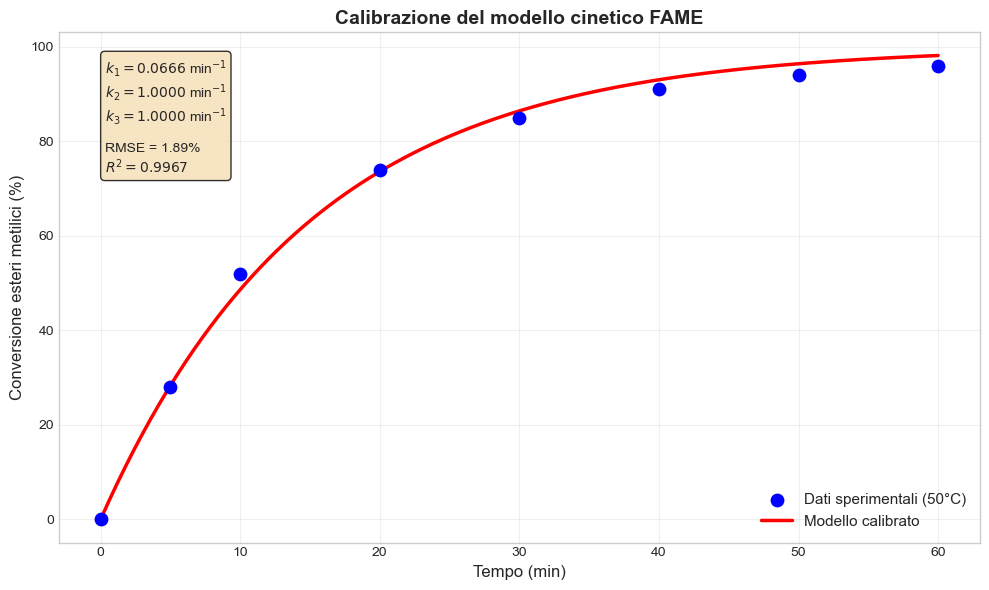


📊 Metriche di qualità del fit:
RMSE = 1.89%
MAE = 1.52%
R² = 0.9967


In [11]:
# Genera la curva con parametri ottimizzati
t_smooth = np.linspace(0, 60, 200)
solution_opt = solve_kinetics(initial_C, t_smooth, k_opt)
conversion_opt = calculate_conversion(solution_opt)

# Calcola la conversione ai tempi sperimentali
conv_pred = model_for_fitting(t_exp, k1_opt, k2_opt, k3_opt)

# Calcola metriche di errore
mse = np.mean((conv_pred - conv_exp * 100) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(conv_pred - conv_exp * 100))
r2 = 1 - np.sum((conv_pred - conv_exp * 100) ** 2) / np.sum((conv_exp * 100 - np.mean(conv_exp * 100)) ** 2)

# Crea il grafico
fig, ax = plt.subplots(figsize=(10, 6))

# Dati sperimentali
ax.scatter(t_exp, conv_exp * 100, color='blue', s=80, zorder=5, 
           label='Dati sperimentali (50°C)')

# Modello calibrato
ax.plot(t_smooth, conversion_opt, 'r-', linewidth=2.5, 
        label='Modello calibrato')

ax.set_xlabel('Tempo (min)', fontsize=12)
ax.set_ylabel('Conversione esteri metilici (%)', fontsize=12)
ax.set_title('Calibrazione del modello cinetico FAME', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

# Aggiungi un riquadro con le metriche
textstr = f'$k_1 = {k1_opt:.4f}$ min$^{{-1}}$\n$k_2 = {k2_opt:.4f}$ min$^{{-1}}$\n$k_3 = {k3_opt:.4f}$ min$^{{-1}}$\n\nRMSE = {rmse:.2f}%\n$R^2 = {r2:.4f}$'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('../output/kinetics_calibration.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Metriche di qualità del fit:")
print(f"RMSE = {rmse:.2f}%")
print(f"MAE = {mae:.2f}%")
print(f"R² = {r2:.4f}")

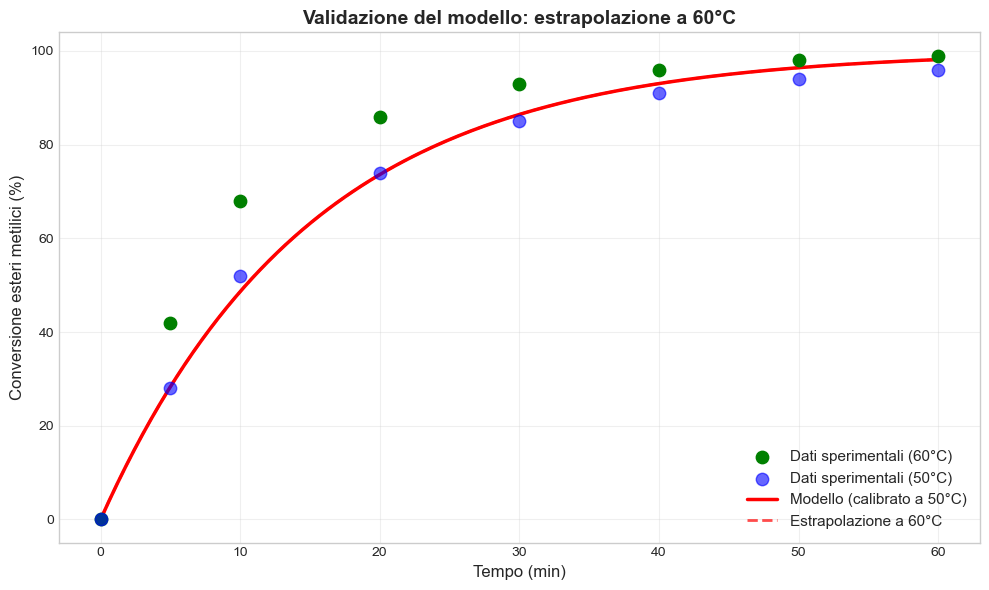

RMSE di validazione (60°C): 9.81%


In [12]:
# Carica dati a 60°C
data_60 = df[df['temperature_c'] == 60]
t_60 = data_60['time_min'].values
conv_60 = data_60['conversion'].values * 100

# Simula con parametri ottimizzati (calibrati a 50°C)
solution_60 = solve_kinetics(initial_C, t_smooth, k_opt)
conversion_60 = calculate_conversion(solution_60)

# Grafico comparativo
fig, ax = plt.subplots(figsize=(10, 6))

# Dati sperimentali
ax.scatter(t_60, conv_60, color='green', s=80, zorder=5, 
           label='Dati sperimentali (60°C)')
ax.scatter(t_exp, conv_exp * 100, color='blue', s=80, zorder=5, alpha=0.6,
           label='Dati sperimentali (50°C)')

# Modello
ax.plot(t_smooth, conversion_opt, 'r-', linewidth=2.5, 
        label='Modello (calibrato a 50°C)')
ax.plot(t_smooth, conversion_60, 'r--', linewidth=2, alpha=0.7,
        label='Estrapolazione a 60°C')

ax.set_xlabel('Tempo (min)', fontsize=12)
ax.set_ylabel('Conversione esteri metilici (%)', fontsize=12)
ax.set_title('Validazione del modello: estrapolazione a 60°C', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/kinetics_validation.png', dpi=300, bbox_inches='tight')
plt.show()

# Calcola errore di validazione
conv_60_pred = np.interp(t_60, t_smooth, conversion_60)
rmse_val = np.sqrt(np.mean((conv_60_pred - conv_60) ** 2))
print(f"RMSE di validazione (60°C): {rmse_val:.2f}%")